# Deep Learning Assignment: Convolutional Neural Networks on Fashion MNIST

This notebook implements and experiments with convolutional neural networks (CNNs) using the [Fashion MNIST](https://en.wikipedia.org/wiki/Fashion_MNIST) dataset, a collection of 60 000 28×28 grayscale images of Zalando fashion products across 10 categories. The goal is to explore how different CNN configurations affect classification performance.

We begin by loading and inspecting the data, then normalize and prepare it for training. Several CNN architectures are defined and trained on the same data with variations in kernel size, layer depth, stride, and pooling strategy. After training, we evaluate models using accuracy, precision, recall, and confusion matrices, and summarize the results.


In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

Load and Preprocess Data

In [2]:
# Load the Fashion MNIST dataset from Keras
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Display dataset shapes
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Normalize pixel values to the range [0,1]
train_images = train_images.astype('float32') / 255.0
test_images  = test_images.astype('float32') / 255.0

# Reshape images to include channel dimension (28×28×1)
train_images = np.expand_dims(train_images, -1)
test_images  = np.expand_dims(test_images, -1)

# Convert labels to categorical one‑hot encoding
num_classes = 10
train_labels_cat = keras.utils.to_categorical(train_labels, num_classes)
test_labels_cat  = keras.utils.to_categorical(test_labels, num_classes)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


Plot Sample Images

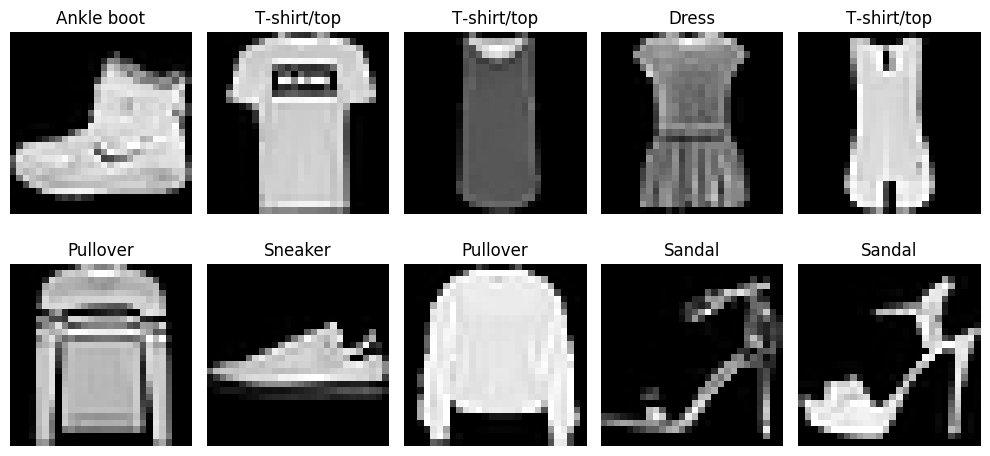

In [3]:
# Plot a few sample images with their labels
class_names = ['T‑shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(train_images[i].squeeze(), cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


Define CNN Building Function

In [4]:
def build_cnn(input_shape=(28,28,1), num_filters=[32,64], kernel_size=3, strides=1, pooling='max'):
    # Builds a simple CNN with configurable parameters.
    # Arguments:
    #   input_shape: Shape of input image including channels.
    #   num_filters: List of filters for successive convolutional layers.
    #   kernel_size: Size of the convolution kernels (int or tuple).
    #   strides: Stride for convolution layers.
    #   pooling: 'max' for MaxPooling2D or 'average' for AveragePooling2D.
    # Returns:
    #   Compiled Keras model ready for training.
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    for f in num_filters:
        model.add(layers.Conv2D(f, kernel_size=kernel_size, strides=strides, activation='relu', padding='same'))
        if pooling == 'max':
            model.add(layers.MaxPooling2D(pool_size=(2,2)))
        else:
            model.add(layers.AveragePooling2D(pool_size=(2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


Train Baseline Model

In [5]:
# Build baseline model with default parameters
baseline_model = build_cnn(num_filters=[32,64], kernel_size=3, strides=1, pooling='max')

# Train the model
history_baseline = baseline_model.fit(
    train_images, train_labels_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Evaluate on the test set
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")


Epoch 1/10
422/422 - 58s - 137ms/step - accuracy: 0.7915 - loss: 0.5817 - val_accuracy: 0.8708 - val_loss: 0.3533
Epoch 2/10
422/422 - 79s - 188ms/step - accuracy: 0.8657 - loss: 0.3746 - val_accuracy: 0.8827 - val_loss: 0.3122
Epoch 3/10
422/422 - 54s - 129ms/step - accuracy: 0.8845 - loss: 0.3227 - val_accuracy: 0.9015 - val_loss: 0.2720
Epoch 4/10
422/422 - 82s - 194ms/step - accuracy: 0.8963 - loss: 0.2890 - val_accuracy: 0.9023 - val_loss: 0.2560
Epoch 5/10
422/422 - 81s - 193ms/step - accuracy: 0.9048 - loss: 0.2639 - val_accuracy: 0.9092 - val_loss: 0.2424
Epoch 6/10
422/422 - 54s - 129ms/step - accuracy: 0.9117 - loss: 0.2462 - val_accuracy: 0.9088 - val_loss: 0.2376
Epoch 7/10
422/422 - 82s - 195ms/step - accuracy: 0.9166 - loss: 0.2301 - val_accuracy: 0.9142 - val_loss: 0.2275
Epoch 8/10
422/422 - 85s - 201ms/step - accuracy: 0.9213 - loss: 0.2153 - val_accuracy: 0.9155 - val_loss: 0.2256
Epoch 9/10
422/422 - 56s - 132ms/step - accuracy: 0.9246 - loss: 0.2062 - val_accuracy: 

Evaluate Baseline (Confusion Matrix & Report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Confusion matrix:
[[908   0  14  12   2   1  58   0   5   0]
 [  0 982   1  11   2   0   3   0   1   0]
 [ 19   1 885   6  41   0  48   0   0   0]
 [ 20   2  12 920  21   0  25   0   0   0]
 [  1   0  62  29 849   0  57   0   2   0]
 [  0   0   0   0   0 990   0   9   0   1]
 [117   3  65  25  50   0 733   0   7   0]
 [  0   0   0   0   0   6   0 974   0  20]
 [  3   1   1   0   3   2   1   1 988   0]
 [  0   0   1   0   0   6   0  36   0 957]]

Classification report:
              precision    recall  f1-score   support

 T‑shirt/top       0.85      0.91      0.88      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.89      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.88      0.85      0.86      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.79      0.73      0.76      1000
     Sneaker       0.95      0.97      0.96      100

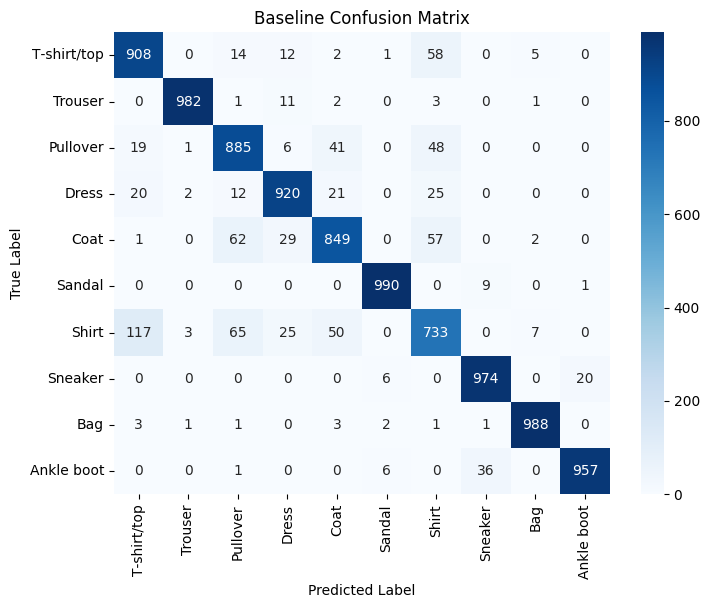

In [6]:
# Predict classes on the test set
baseline_pred_prob = baseline_model.predict(test_images)
baseline_pred = np.argmax(baseline_pred_prob, axis=1)

# Compute confusion matrix and classification report
cm_baseline = confusion_matrix(test_labels, baseline_pred)
print('Confusion matrix:')
print(cm_baseline)

print('\nClassification report:')
print(classification_report(test_labels, baseline_pred, target_names=class_names))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Baseline Confusion Matrix')
plt.show()


Experiment 1: Larger Kernels

In [7]:
# Model with larger kernels (5×5)
model_k5 = build_cnn(num_filters=[32,64], kernel_size=5, strides=1, pooling='max')
history_k5 = model_k5.fit(
    train_images, train_labels_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Evaluate
k5_test_loss, k5_test_acc = model_k5.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy with kernel size 5×5: {k5_test_acc:.4f}")


Epoch 1/10
422/422 - 118s - 279ms/step - accuracy: 0.7764 - loss: 0.6272 - val_accuracy: 0.8567 - val_loss: 0.3856
Epoch 2/10
422/422 - 116s - 274ms/step - accuracy: 0.8601 - loss: 0.3958 - val_accuracy: 0.8847 - val_loss: 0.3086
Epoch 3/10
422/422 - 142s - 335ms/step - accuracy: 0.8801 - loss: 0.3375 - val_accuracy: 0.8962 - val_loss: 0.2795
Epoch 4/10
422/422 - 140s - 331ms/step - accuracy: 0.8928 - loss: 0.2997 - val_accuracy: 0.9043 - val_loss: 0.2543
Epoch 5/10
422/422 - 142s - 336ms/step - accuracy: 0.9011 - loss: 0.2736 - val_accuracy: 0.9028 - val_loss: 0.2586
Epoch 6/10
422/422 - 143s - 339ms/step - accuracy: 0.9079 - loss: 0.2565 - val_accuracy: 0.9143 - val_loss: 0.2357
Epoch 7/10
422/422 - 140s - 332ms/step - accuracy: 0.9127 - loss: 0.2404 - val_accuracy: 0.9062 - val_loss: 0.2615
Epoch 8/10
422/422 - 141s - 335ms/step - accuracy: 0.9178 - loss: 0.2256 - val_accuracy: 0.9167 - val_loss: 0.2291
Epoch 9/10
422/422 - 144s - 341ms/step - accuracy: 0.9219 - loss: 0.2126 - val_a

Experiment 2: Deeper Network

In [8]:
# Model with three convolutional layers
model_deep = build_cnn(num_filters=[32,64,128], kernel_size=3, strides=1, pooling='max')
history_deep = model_deep.fit(
    train_images, train_labels_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Evaluate
_, d_test_acc = model_deep.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy with three convolutional layers: {d_test_acc:.4f}")


Epoch 1/10
422/422 - 88s - 209ms/step - accuracy: 0.7610 - loss: 0.6593 - val_accuracy: 0.8632 - val_loss: 0.3650
Epoch 2/10
422/422 - 135s - 321ms/step - accuracy: 0.8602 - loss: 0.3889 - val_accuracy: 0.8797 - val_loss: 0.3105
Epoch 3/10
422/422 - 80s - 190ms/step - accuracy: 0.8828 - loss: 0.3288 - val_accuracy: 0.8988 - val_loss: 0.2750
Epoch 4/10
422/422 - 77s - 182ms/step - accuracy: 0.8949 - loss: 0.2951 - val_accuracy: 0.8992 - val_loss: 0.2652
Epoch 5/10
422/422 - 82s - 193ms/step - accuracy: 0.9039 - loss: 0.2708 - val_accuracy: 0.9038 - val_loss: 0.2526
Epoch 6/10
422/422 - 81s - 192ms/step - accuracy: 0.9101 - loss: 0.2510 - val_accuracy: 0.9092 - val_loss: 0.2397
Epoch 7/10
422/422 - 83s - 196ms/step - accuracy: 0.9141 - loss: 0.2338 - val_accuracy: 0.9117 - val_loss: 0.2333
Epoch 8/10
422/422 - 76s - 181ms/step - accuracy: 0.9200 - loss: 0.2199 - val_accuracy: 0.9172 - val_loss: 0.2205
Epoch 9/10
422/422 - 78s - 185ms/step - accuracy: 0.9262 - loss: 0.2037 - val_accuracy:

Experiment 3: Stride=2, No Pooling

In [9]:
# Model using stride of 2 and no pooling
model_stride2 = models.Sequential()
model_stride2.add(layers.Input(shape=(28,28,1)))
model_stride2.add(layers.Conv2D(32, kernel_size=3, strides=2, activation='relu', padding='same'))
model_stride2.add(layers.Conv2D(64, kernel_size=3, strides=2, activation='relu', padding='same'))
model_stride2.add(layers.Flatten())
model_stride2.add(layers.Dense(128, activation='relu'))
model_stride2.add(layers.Dropout(0.5))
model_stride2.add(layers.Dense(num_classes, activation='softmax'))

model_stride2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_stride2 = model_stride2.fit(
    train_images, train_labels_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Evaluate
_, s2_test_acc = model_stride2.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy with stride=2 and no pooling: {s2_test_acc:.4f}")


Epoch 1/10
422/422 - 17s - 40ms/step - accuracy: 0.7787 - loss: 0.6220 - val_accuracy: 0.8537 - val_loss: 0.3833
Epoch 2/10
422/422 - 20s - 48ms/step - accuracy: 0.8553 - loss: 0.4055 - val_accuracy: 0.8777 - val_loss: 0.3310
Epoch 3/10
422/422 - 15s - 36ms/step - accuracy: 0.8749 - loss: 0.3537 - val_accuracy: 0.8815 - val_loss: 0.3074
Epoch 4/10
422/422 - 20s - 49ms/step - accuracy: 0.8841 - loss: 0.3202 - val_accuracy: 0.8935 - val_loss: 0.2774
Epoch 5/10
422/422 - 15s - 35ms/step - accuracy: 0.8911 - loss: 0.2986 - val_accuracy: 0.9027 - val_loss: 0.2645
Epoch 6/10
422/422 - 21s - 50ms/step - accuracy: 0.8990 - loss: 0.2789 - val_accuracy: 0.9002 - val_loss: 0.2671
Epoch 7/10
422/422 - 20s - 48ms/step - accuracy: 0.9021 - loss: 0.2637 - val_accuracy: 0.9017 - val_loss: 0.2590
Epoch 8/10
422/422 - 15s - 36ms/step - accuracy: 0.9094 - loss: 0.2466 - val_accuracy: 0.9028 - val_loss: 0.2569
Epoch 9/10
422/422 - 16s - 37ms/step - accuracy: 0.9120 - loss: 0.2330 - val_accuracy: 0.9063 - 

Experiment 4: Average Pooling

In [10]:
# Model using average pooling
model_avgpool = build_cnn(num_filters=[32,64], kernel_size=3, strides=1, pooling='average')
history_avgpool = model_avgpool.fit(
    train_images, train_labels_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# Evaluate
_, avg_test_acc = model_avgpool.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy with average pooling: {avg_test_acc:.4f}")


Epoch 1/10
422/422 - 48s - 113ms/step - accuracy: 0.7555 - loss: 0.6778 - val_accuracy: 0.8470 - val_loss: 0.4092
Epoch 2/10
422/422 - 46s - 109ms/step - accuracy: 0.8415 - loss: 0.4434 - val_accuracy: 0.8610 - val_loss: 0.3624
Epoch 3/10
422/422 - 46s - 109ms/step - accuracy: 0.8612 - loss: 0.3882 - val_accuracy: 0.8792 - val_loss: 0.3292
Epoch 4/10
422/422 - 82s - 194ms/step - accuracy: 0.8731 - loss: 0.3547 - val_accuracy: 0.8805 - val_loss: 0.3159
Epoch 5/10
422/422 - 84s - 198ms/step - accuracy: 0.8808 - loss: 0.3315 - val_accuracy: 0.8905 - val_loss: 0.2862
Epoch 6/10
422/422 - 81s - 191ms/step - accuracy: 0.8886 - loss: 0.3114 - val_accuracy: 0.9012 - val_loss: 0.2773
Epoch 7/10
422/422 - 82s - 194ms/step - accuracy: 0.8923 - loss: 0.2996 - val_accuracy: 0.8995 - val_loss: 0.2633
Epoch 8/10
422/422 - 82s - 194ms/step - accuracy: 0.8961 - loss: 0.2831 - val_accuracy: 0.9038 - val_loss: 0.2559
Epoch 9/10
422/422 - 46s - 109ms/step - accuracy: 0.9012 - loss: 0.2741 - val_accuracy: 

Summary of Test Accuracies

In [11]:
# Summarize test accuracies
print('Test accuracy summary:')
print(f"Baseline (3×3 kernels, 2 conv layers, max pool): {baseline_test_acc:.4f}")
print(f"Larger kernels (5×5): {k5_test_acc:.4f}")
print(f"Additional conv layer: {d_test_acc:.4f}")
print(f"Stride=2, no pooling: {s2_test_acc:.4f}")
print(f"Average pooling: {avg_test_acc:.4f}")


Test accuracy summary:
Baseline (3×3 kernels, 2 conv layers, max pool): 0.9186
Larger kernels (5×5): 0.9186
Additional conv layer: 0.9128
Stride=2, no pooling: 0.9077
Average pooling: 0.9024
